In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HouseValue"] = housing.target

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HouseValue  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   

In [4]:
print("missing values")
print(df.isnull().sum())

missing values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64


In [5]:
before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print("Duplicates removed:", before - after)

Duplicates removed: 0


In [6]:
for column in df.columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower) &
        (df[column] <= upper)
    ]

print("Final Dataset Shape:")
print(df.shape)

Final Dataset Shape:
(16232, 9)


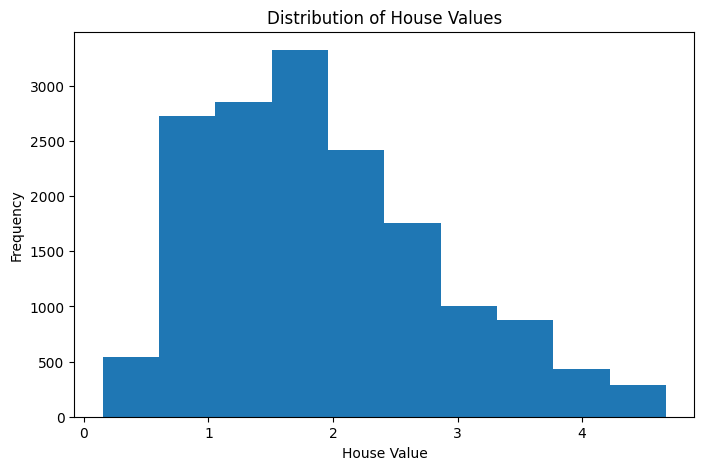

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["HouseValue"])

plt.title("Distribution of House Values")
plt.xlabel("House Value")
plt.ylabel("Frequency")

plt.show()

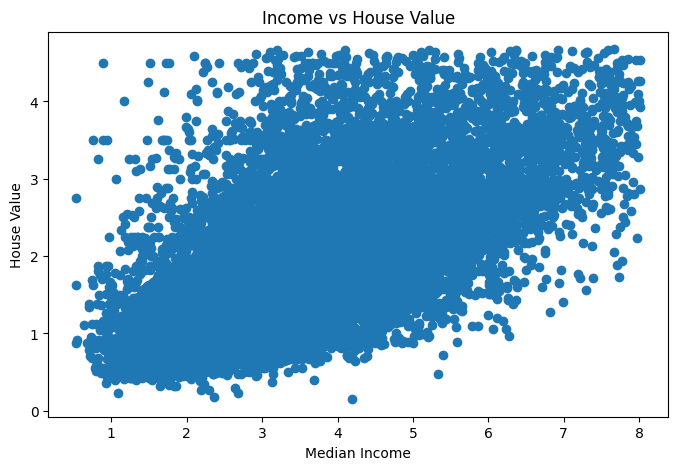

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["MedInc"],
    df["HouseValue"]
)

plt.xlabel("Median Income")
plt.ylabel("House Value")

plt.title("Income vs House Value")

plt.show()

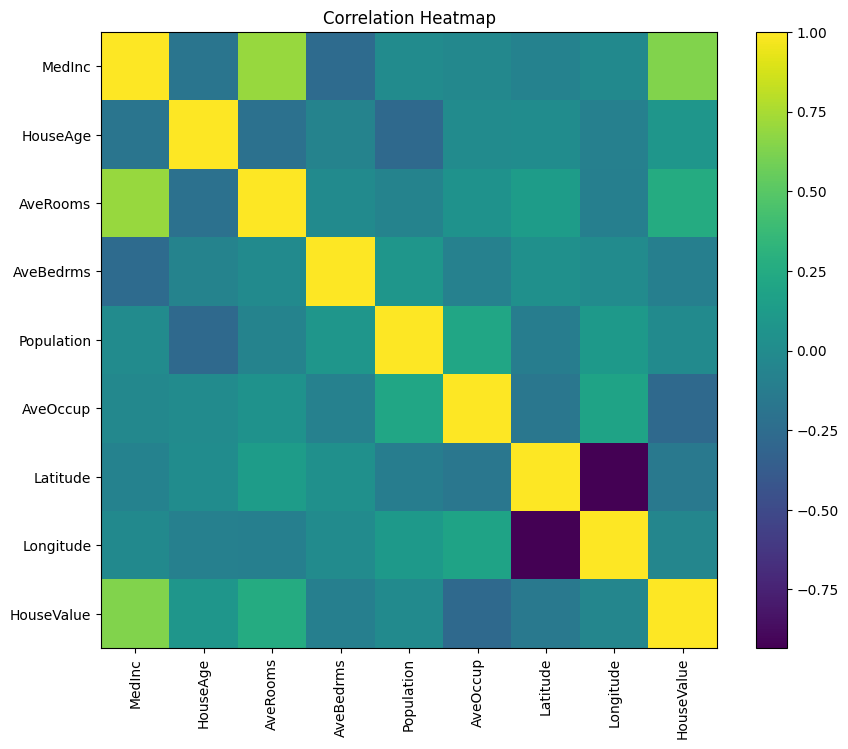

In [9]:
corr = df.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
print("Key Findings")

print("1. Median income has a strong relationship with house value")
print("2. Outliers were removed for better analysis")
print("3. Data preprocessing improved data quality")
print("4. Visualizations revealed patterns in housing prices")

Key Findings
1. Median income has a strong relationship with house value
2. Outliers were removed for better analysis
3. Data preprocessing improved data quality
4. Visualizations revealed patterns in housing prices
